In [1]:
# =============================================================================
# Posterior on the Baseline: Bayesian Tennis Tournament Predictions
# Full pipeline: Data → Static BT → Dynamic BT → Covariates → Eval → Simulation
# =============================================================================

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from scipy.special import expit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


/Users/liuzirui/Documents/Bayesian/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
# =============================================================================
# SECTION 1: DATA LOADING & PREPROCESSING
# Jeff Sackmann ATP CSVs: https://github.com/JeffSackmann/tennis_atp
# =============================================================================

def load_atp_data(years: list[int], data_dir: str = "data/") -> pd.DataFrame:
    """Load and concatenate Jeff Sackmann ATP yearly CSVs."""
    dfs = []
    for yr in years:
        path = f"{data_dir}atp_matches_{yr}.csv"
        df = pd.read_csv(path, low_memory=False)
        df["year"] = yr
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    data["tourney_date"] = pd.to_datetime(
        data["tourney_date"].astype(str), format="%Y%m%d"
    )
    data = data[
        ["tourney_date", "tourney_id", "tourney_name", "tourney_level",
         "surface", "winner_id", "winner_name", "loser_id", "loser_name"]
    ].dropna(subset=["winner_id", "loser_id"])
    return data.sort_values("tourney_date").reset_index(drop=True)


def encode_players(data: pd.DataFrame):
    """Encode all players to integer indices."""
    all_players = pd.concat([data["winner_name"], data["loser_name"]]).unique()
    player2idx = {p: i for i, p in enumerate(all_players)}
    idx2player = {i: p for p, i in player2idx.items()}
    data = data.copy()
    data["winner_idx"] = data["winner_name"].map(player2idx)
    data["loser_idx"]  = data["loser_name"].map(player2idx)
    return data, player2idx, idx2player


def assign_time_periods(data: pd.DataFrame, freq: str = "QS") -> pd.DataFrame:
    """Assign integer time-period index to each match."""
    data = data.copy()
    periods = pd.period_range(
        data["tourney_date"].min(), data["tourney_date"].max(), freq=freq
    )
    period_map = {p: i for i, p in enumerate(periods)}
    data["period"] = data["tourney_date"].dt.to_period(freq).map(period_map)
    data["period"] = data["period"].fillna(0).astype(int)
    return data, len(periods)


def train_test_split_by_tournament(data: pd.DataFrame, test_tournament: str):
    """Split data: held-out test = all matches in `test_tournament`."""
    test_mask = data["tourney_name"] == test_tournament
    return data[~test_mask].copy(), data[test_mask].copy()


# ── RUN ───────────────────────────────────────────────────────────────────────
print("Loading ATP data...")
data = load_atp_data(years=list(range(2018, 2024)), data_dir="data/tennis_atp-master/")
data, player2idx, idx2player = encode_players(data)
data, n_periods = assign_time_periods(data, freq="Q")
n_players = len(player2idx)

HELD_OUT_TOURNAMENT = "Wimbledon"
train_df, test_df = train_test_split_by_tournament(data, HELD_OUT_TOURNAMENT)
last_period = train_df["period"].max()

print(f"  {len(data)} matches | {n_players} players | {n_periods} periods")
print(f"  Train: {len(train_df)} | Test: {len(test_df)} ({HELD_OUT_TOURNAMENT})")


Loading ATP data...
  15801 matches | 845 players | 24 periods
  Train: 15166 | Test: 635 (Wimbledon)


In [4]:
# =============================================================================
# SECTION 2: STATIC (BASELINE) BRADLEY-TERRY MODEL
# One fixed skill theta_i per player; no time variation.
# Fitted with NUTS (MCMC) and ADVI (VI).
# =============================================================================

def build_static_bt_model(train_df: pd.DataFrame, n_players: int):
    """
    Baseline BT model.
      theta[i] ~ ZeroSumNormal(sigma=1)
      logit P(winner beats loser) = theta[winner] - theta[loser]
      y_obs ~ Bernoulli(p)
    """
    winner_idx = train_df["winner_idx"].values
    loser_idx  = train_df["loser_idx"].values
    y = np.ones(len(train_df), dtype=int)

    with pm.Model() as model:
        theta    = pm.ZeroSumNormal("theta", sigma=1.0, shape=n_players)
        log_odds = theta[winner_idx] - theta[loser_idx]
        p        = pm.Deterministic("p", pm.math.sigmoid(log_odds))
        pm.Bernoulli("y_obs", p=p, observed=y)
    return model


def fit_static_bt_mcmc(model, draws=1000, tune=1000, chains=4):
    """Fit static BT via NUTS (MCMC)."""
    with model:
        trace = pm.sample(
            draws=draws, tune=tune, chains=chains,
            target_accept=0.9, return_inferencedata=True
        )
    return trace


def fit_static_bt_vi(model, n_iterations=50_000):
    """Fit static BT via ADVI (Variational Inference)."""
    with model:
        approx = pm.fit(
            n=n_iterations, method="advi",
            callbacks=[pm.callbacks.CheckParametersConvergence(tolerance=1e-4)]
        )
    return approx


# ── RUN ───────────────────────────────────────────────────────────────────────
print("Fitting Static BT (MCMC / NUTS)...")
static_model_mcmc = build_static_bt_model(train_df, n_players)
trace_static_mcmc = fit_static_bt_mcmc(static_model_mcmc, draws=1000, tune=1000)

print("\nFitting Static BT (VI / ADVI)...")
static_model_vi  = build_static_bt_model(train_df, n_players)
approx_static_vi = fit_static_bt_vi(static_model_vi)
print("Done.")


Fitting Static BT (MCMC / NUTS)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.



Fitting Static BT (VI / ADVI)...


Output()

Finished [100%]: Average Loss = 9,763.4


Done.


In [5]:
# =============================================================================
# SECTION 3: DYNAMIC BRADLEY-TERRY MODEL  (time-varying skill)
# theta[i, t] follows a random walk over quarterly periods.
# Fitted with NUTS (MCMC).
# =============================================================================

def build_dynamic_bt_model(train_df: pd.DataFrame, n_players: int, n_periods: int):
    """
    Dynamic BT with random-walk skill.
      theta[i,0]  ~ Normal(0, 1)
      theta[i,t]  ~ Normal(theta[i,t-1], sigma^2)   t > 0
      logit P     = theta[winner,t] - theta[loser,t]
      y_obs       ~ Bernoulli(p)
    """
    winner_idx = train_df["winner_idx"].values
    loser_idx  = train_df["loser_idx"].values
    period_idx = train_df["period"].values
    y = np.ones(len(train_df), dtype=int)

    with pm.Model() as model:
        sigma       = pm.HalfNormal("sigma", sigma=0.2)
        theta_0     = pm.Normal("theta_0", mu=0, sigma=1, shape=n_players)
        innovations = pm.Normal("innovations", mu=0, sigma=sigma,
                                shape=(n_players, n_periods - 1))
        theta = pm.Deterministic(
            "theta",
            pt.concatenate(
                [theta_0[:, None],
                 theta_0[:, None] + pt.cumsum(innovations, axis=1)],
                axis=1
            )
        )
        log_odds = theta[winner_idx, period_idx] - theta[loser_idx, period_idx]
        p        = pm.Deterministic("p", pm.math.sigmoid(log_odds))
        pm.Bernoulli("y_obs", p=p, observed=y)
    return model


def fit_dynamic_bt_mcmc(model, draws=500, tune=500, chains=4):
    """Fit dynamic BT via NUTS (numpyro backend for speed)."""
    with model:
        trace = pm.sample(
            draws=draws, tune=tune, chains=chains,
            target_accept=0.9, return_inferencedata=True,
            nuts_sampler="numpyro"
        )
    return trace


# ── RUN ───────────────────────────────────────────────────────────────────────
print("Fitting Dynamic BT (MCMC / NUTS)...")
dynamic_model      = build_dynamic_bt_model(train_df, n_players, n_periods)
trace_dynamic_mcmc = fit_dynamic_bt_mcmc(dynamic_model, draws=500, tune=500)
print("Done.")


Fitting Dynamic BT (MCMC / NUTS)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Done.


Initializing NUTS using jitter+adapt_diag...


Fitting Extended BT with surface covariates (MCMC)...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_clay, beta_grass, sigma, theta_0, innovations]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 165 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


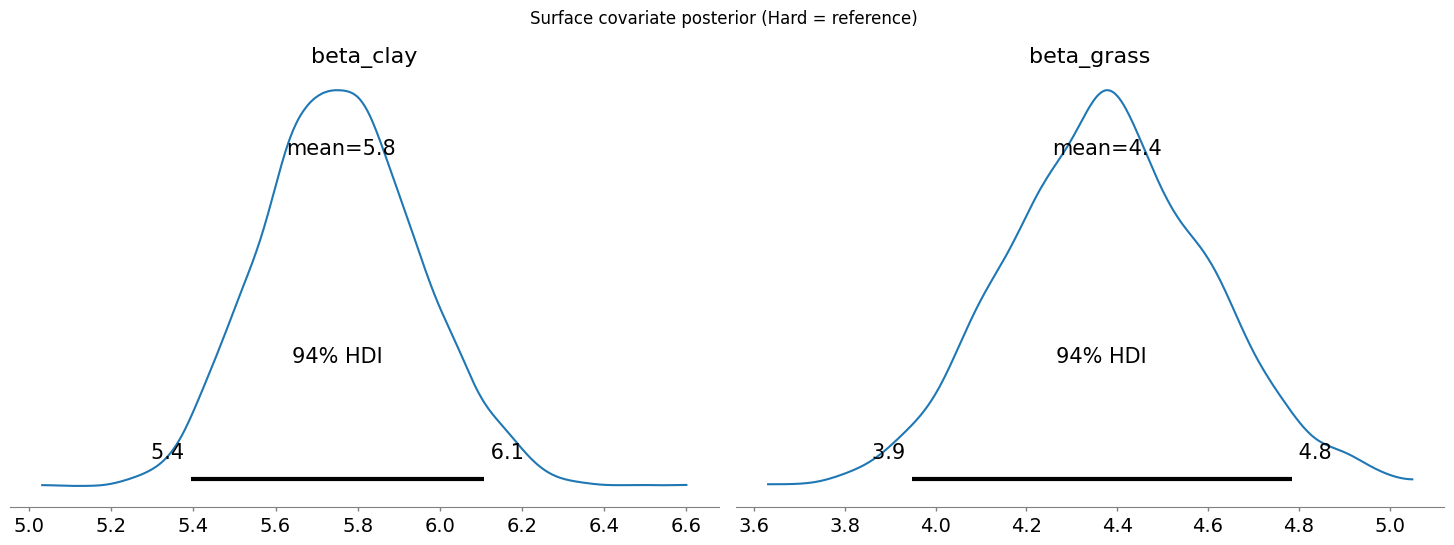

Done.


In [6]:
# =============================================================================
# SECTION 4: EXTENDED BT WITH SURFACE COVARIATES  (optional enrichment)
# log-odds = (theta[winner,t] - theta[loser,t]) + beta_clay*clay + beta_grass*grass
# Hard court is the reference category (beta_hard = 0).
# =============================================================================

def encode_surface(data: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode surface, dropping Hard as reference."""
    data = data.copy()
    data["surface_clean"] = data["surface"].str.strip().str.capitalize()
    for s in ["Clay", "Grass"]:
        data[f"surface_{s}"] = (data["surface_clean"] == s).astype(int)
    return data


def build_bt_with_covariates(train_df, n_players, n_periods, use_dynamic=True):
    """BT model (optionally dynamic) + surface covariates."""
    train_df   = encode_surface(train_df)
    winner_idx = train_df["winner_idx"].values
    loser_idx  = train_df["loser_idx"].values
    period_idx = train_df["period"].values
    clay_vals  = train_df["surface_Clay"].values.astype(float)
    grass_vals = train_df["surface_Grass"].values.astype(float)
    y = np.ones(len(train_df), dtype=int)

    with pm.Model() as model:
        beta_clay  = pm.Normal("beta_clay",  mu=0, sigma=0.5)
        beta_grass = pm.Normal("beta_grass", mu=0, sigma=0.5)

        if use_dynamic:
            sigma       = pm.HalfNormal("sigma", sigma=0.2)
            theta_0     = pm.Normal("theta_0", mu=0, sigma=1, shape=n_players)
            innovations = pm.Normal("innovations", mu=0, sigma=sigma,
                                    shape=(n_players, n_periods - 1))
            theta = pm.Deterministic(
                "theta",
                pt.concatenate(
                    [theta_0[:, None],
                     theta_0[:, None] + pt.cumsum(innovations, axis=1)],
                    axis=1
                )
            )
            skill_diff = theta[winner_idx, period_idx] - theta[loser_idx, period_idx]
        else:
            theta      = pm.ZeroSumNormal("theta", sigma=1.0, shape=n_players)
            skill_diff = theta[winner_idx] - theta[loser_idx]

        log_odds = skill_diff + beta_clay * clay_vals + beta_grass * grass_vals
        p        = pm.Deterministic("p", pm.math.sigmoid(log_odds))
        pm.Bernoulli("y_obs", p=p, observed=y)
    return model


# ── RUN ───────────────────────────────────────────────────────────────────────
print("Fitting Extended BT with surface covariates (MCMC)...")
ext_model = build_bt_with_covariates(train_df, n_players, n_periods, use_dynamic=True)
with ext_model:
    trace_ext = pm.sample(500, tune=500, target_accept=0.9, return_inferencedata=True)

az.plot_posterior(trace_ext, var_names=["beta_clay", "beta_grass"])
plt.suptitle("Surface covariate posterior (Hard = reference)")
plt.tight_layout()
plt.savefig("surface_effects.png", dpi=150)
plt.show()
print("Done.")



Diagnostics: Static BT MCMC
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
theta[0]   0.485  0.284  -0.032    1.029      0.004    0.005    4014.0   
theta[1]   0.938  0.164   0.649    1.262      0.003    0.003    3871.0   
theta[2]   0.854  0.142   0.573    1.105      0.002    0.003    3294.0   
theta[3]   0.353  0.191  -0.000    0.703      0.003    0.003    5499.0   
theta[4]   0.781  0.140   0.514    1.037      0.002    0.003    4022.0   
theta[5]   0.284  0.181  -0.064    0.622      0.003    0.003    4758.0   
theta[6]   1.392  0.156   1.103    1.692      0.002    0.002    4646.0   
theta[7]   1.773  0.145   1.515    2.054      0.002    0.002    3636.0   
theta[8]   0.588  0.167   0.283    0.896      0.003    0.003    4074.0   
theta[9]   1.903  0.124   1.670    2.135      0.002    0.002    2715.0   
theta[10]  2.112  0.120   1.887    2.325      0.002    0.002    3097.0   
theta[11]  0.441  0.202   0.051    0.801      0.003    0.004    5584.0   
theta[12]

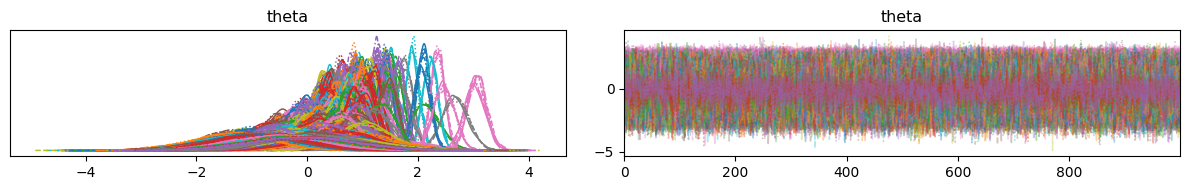


Diagnostics: Dynamic BT MCMC
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma        0.187  0.011   0.168    0.207      0.003    0.001      13.0   
theta_0[0]   0.532  0.326  -0.079    1.117      0.007    0.007    2232.0   
theta_0[1]   0.853  0.298   0.298    1.403      0.006    0.006    2387.0   
theta_0[2]   0.782  0.303   0.243    1.389      0.007    0.007    2142.0   
theta_0[3]   0.467  0.327  -0.133    1.080      0.008    0.008    1577.0   
theta_0[4]   0.333  0.337  -0.269    0.998      0.008    0.007    1689.0   
theta_0[5]   0.160  0.361  -0.500    0.861      0.008    0.009    1839.0   
theta_0[6]   1.390  0.292   0.772    1.894      0.007    0.007    1901.0   
theta_0[7]   2.142  0.288   1.622    2.713      0.007    0.007    1888.0   
theta_0[8]   0.732  0.295   0.148    1.250      0.006    0.006    2103.0   
theta_0[9]   1.069  0.304   0.507    1.651      0.008    0.007    1412.0   
theta_0[10]  1.543  0.299   0.963    2.088      0.011    0

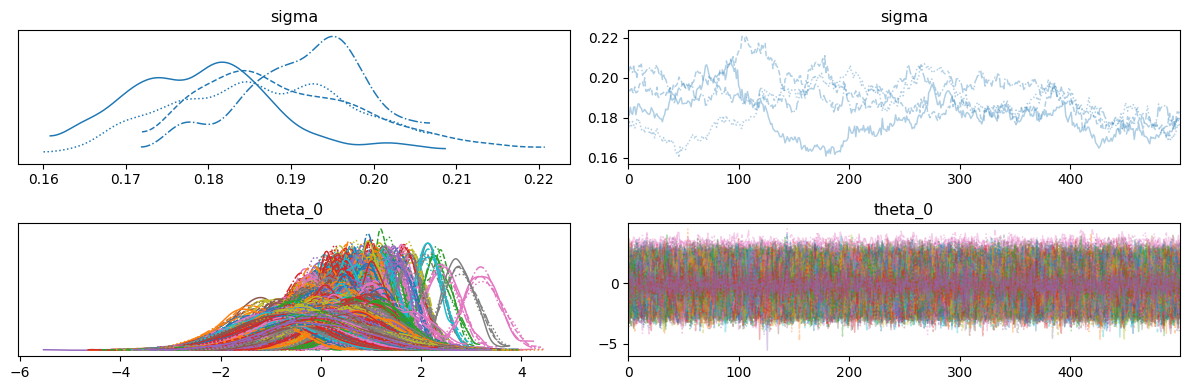

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.187,0.011,0.168,0.207,0.003,0.001,13.0,59.0,1.25
theta_0[0],0.532,0.326,-0.079,1.117,0.007,0.007,2232.0,1365.0,1.00
theta_0[1],0.853,0.298,0.298,1.403,0.006,0.006,2387.0,1794.0,1.00
theta_0[2],0.782,0.303,0.243,1.389,0.007,0.007,2142.0,1293.0,1.00
theta_0[3],0.467,0.327,-0.133,1.080,0.008,0.008,1577.0,1147.0,1.00
...,...,...,...,...,...,...,...,...,...
theta_0[840],-0.246,0.918,-2.032,1.410,0.016,0.022,3247.0,1531.0,1.01
theta_0[841],-0.245,0.936,-1.991,1.492,0.017,0.021,2897.0,1529.0,1.00
theta_0[842],-0.209,0.896,-1.867,1.539,0.014,0.024,3930.0,1552.0,1.00
theta_0[843],-0.206,0.931,-1.977,1.502,0.016,0.025,3326.0,1449.0,1.00


In [7]:
# =============================================================================
# SECTION 5: MCMC DIAGNOSTICS
# R-hat and ESS to verify chain convergence; trace plots for key parameters.
# =============================================================================

def run_diagnostics(trace, var_names: list = None, title: str = ""):
    """Print R-hat / ESS summary and plot trace for key parameters."""
    summary = az.summary(trace, var_names=var_names)
    print(f"\n{'='*60}\nDiagnostics: {title}\n{'='*60}")
    print(summary.head(20))
    rhat_bad = summary[summary["r_hat"] > 1.01]
    if len(rhat_bad) > 0:
        print(f"\nWARNING: {len(rhat_bad)} parameters have R-hat > 1.01")
    else:
        print("\nAll R-hat < 1.01 ✓")
    if var_names:
        az.plot_trace(trace, var_names=var_names[:2])
        plt.tight_layout()
        plt.savefig(f"trace_{title.replace(' ', '_')}.png", dpi=150)
        plt.show()
    return summary


# ── RUN ───────────────────────────────────────────────────────────────────────
run_diagnostics(trace_static_mcmc,  var_names=["theta"],           title="Static BT MCMC")
run_diagnostics(trace_dynamic_mcmc, var_names=["sigma", "theta_0"], title="Dynamic BT MCMC")


In [8]:
# =============================================================================
# SECTION 6: PREDICTION HELPERS
# Shared (player_i, player_j) view: y_true=1 if player_i wins.
# =============================================================================

def make_binary_labels_for_test(df: pd.DataFrame):
    """
    Build (player_i, player_j, y_true) for evaluation.
    View: smaller index = player_i.  y_true=1 if player_i won.
    Guarantees y_true has both 0s and 1s.
    """
    p_win    = df["winner_idx"].values
    p_lose   = df["loser_idx"].values
    player_i = np.minimum(p_win, p_lose)
    player_j = np.maximum(p_win, p_lose)
    y_true   = (p_win == player_i).astype(int)
    return player_i, player_j, y_true


def predict_mcmc_static(trace, player_i, player_j):
    """P(i beats j) — posterior mean, static BT MCMC."""
    theta_s  = trace.posterior["theta"].values
    theta_f  = theta_s.reshape(-1, theta_s.shape[-1])
    log_odds = theta_f[:, player_i] - theta_f[:, player_j]
    return (1 / (1 + np.exp(-log_odds))).mean(axis=0)


def predict_vi_static(approx, model, player_i, player_j, n_samples=2000):
    """P(i beats j) — posterior mean, static BT VI."""
    with model:
        post = approx.sample(n_samples)
    theta_s  = post.posterior["theta"].values
    theta_f  = theta_s.reshape(-1, theta_s.shape[-1])
    log_odds = theta_f[:, player_i] - theta_f[:, player_j]
    return (1 / (1 + np.exp(-log_odds))).mean(axis=0)


def predict_mcmc_dynamic(trace, player_i, player_j, last_period):
    """P(i beats j) at last_period — posterior mean, dynamic BT MCMC."""
    theta_s  = trace.posterior["theta"].values
    theta_f  = theta_s.reshape(-1, theta_s.shape[2], theta_s.shape[3])
    log_odds = theta_f[:, player_i, last_period] - theta_f[:, player_j, last_period]
    return (1 / (1 + np.exp(-log_odds))).mean(axis=0)


def predict_logreg(theta_mle, player_i, player_j):
    """P(i beats j) — frequentist MLE logistic regression."""
    return expit(theta_mle[player_i] - theta_mle[player_j])


# ── RUN ───────────────────────────────────────────────────────────────────────
player_i_test, player_j_test, y_true_test = make_binary_labels_for_test(test_df)
print(f"Test set: {len(y_true_test)} matches  |  "
      f"y=1 (player_i wins): {y_true_test.sum()}  |  "
      f"y=0 (player_j wins): {(1-y_true_test).sum()}")


Test set: 635 matches  |  y=1 (player_i wins): 346  |  y=0 (player_j wins): 289


In [12]:
# =============================================================================
# SECTION 7: FREQUENTIST BASELINE — BT DIRECT MLE (scipy L-BFGS-B)
# -----------------------------------------------------------------------------
# The BT log-likelihood given observed outcomes is:
#
#   log L(theta) = sum_m  log sigmoid( theta[winner_m] - theta[loser_m] )
#                = -sum_m  log(1 + exp(-(theta[winner_m] - theta[loser_m])))
#
# We maximise this directly via scipy L-BFGS-B with an analytic gradient.
# theta[0] = 0 is fixed as the reference player for identifiability.
#
# No label manipulation or data duplication needed — the likelihood is
# defined purely on observed (winner, loser) pairs.
# =============================================================================
from scipy.optimize import minimize
def fit_bt_mle(train_df: pd.DataFrame, n_players: int):
    """
    Fit BT via direct MLE using L-BFGS-B.
    theta[0] fixed to 0 (reference player) for identifiability.
    Returns:
      theta_mle : np.ndarray, shape (n_players,)
      result    : scipy OptimizeResult
    """
    winner_idx = train_df["winner_idx"].values
    loser_idx  = train_df["loser_idx"].values

    def neg_log_likelihood(theta_free):
        """NLL = -sum log sigmoid(theta[w] - theta[l])."""
        theta    = np.concatenate([[0.0], theta_free])
        log_odds = theta[winner_idx] - theta[loser_idx]
        # log(1 + exp(-x)) is numerically stable via np.logaddexp(0, -x)
        return np.logaddexp(0.0, -log_odds).sum()

    def grad_neg_log_likelihood(theta_free):
        """Analytic gradient of NLL w.r.t. theta_free."""
        theta    = np.concatenate([[0.0], theta_free])
        log_odds = theta[winner_idx] - theta[loser_idx]
        # p_loss[m] = sigmoid(-log_odds[m]) = P(loser wins)
        p_loss   = expit(-log_odds)
        grad     = np.zeros(n_players)
        np.add.at(grad, winner_idx,  -p_loss)  # dNLL/d(theta_winner) = -p_loss
        np.add.at(grad, loser_idx,    p_loss)  # dNLL/d(theta_loser)  = +p_loss
        return grad[1:]  # theta[0] is fixed, drop its gradient

    result = minimize(
        neg_log_likelihood,
        x0=np.zeros(n_players - 1),
        jac=grad_neg_log_likelihood,
        method="L-BFGS-B",
        options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8}
    )

    theta_mle     = np.zeros(n_players)
    theta_mle[1:] = result.x
    return theta_mle, result


# ── RUN ───────────────────────────────────────────────────────────────────────
print("Fitting BT via direct MLE (L-BFGS-B)...")
theta_mle, mle_result = fit_bt_mle(train_df, n_players)
print(f"  Converged : {mle_result.success}")
print(f"  Iterations: {mle_result.nit}")
print(f"  Final NLL : {mle_result.fun:.2f}")

top10 = (pd.Series(theta_mle, index=[idx2player[i] for i in range(n_players)])
           .sort_values(ascending=False)
           .head(10))
print("\nTop 10 players by MLE skill estimate:")
print(top10.round(3).to_string())


Fitting BT via direct MLE (L-BFGS-B)...
  Converged : True
  Iterations: 3245
  Final NLL : 8833.16

Top 10 players by MLE skill estimate:
Jurabek Karimov        21.942
Gustavo Heide          20.479
Duilio Beretta         19.345
Matwe Middelkoop       19.203
Daniel Vallejo         16.071
Orlando Luz            14.240
Dragos Dima            13.504
Alvaro Guillen Meza    13.489
Sylvestre Monnou       11.854
Christopher Rungkat    11.070



Evaluation on held-out tournament: Wimbledon
  [Static BT — MCMC (NUTS)     ]  Log Loss: 0.5680  |  Brier Score: 0.1938
  [Static BT — VI (ADVI)       ]  Log Loss: 0.5683  |  Brier Score: 0.1939
  [Dynamic BT — MCMC (NUTS)    ]  Log Loss: 0.5816  |  Brier Score: 0.2003
  [Freq. LogReg — MLE          ]  Log Loss: 0.6214  |  Brier Score: 0.1952


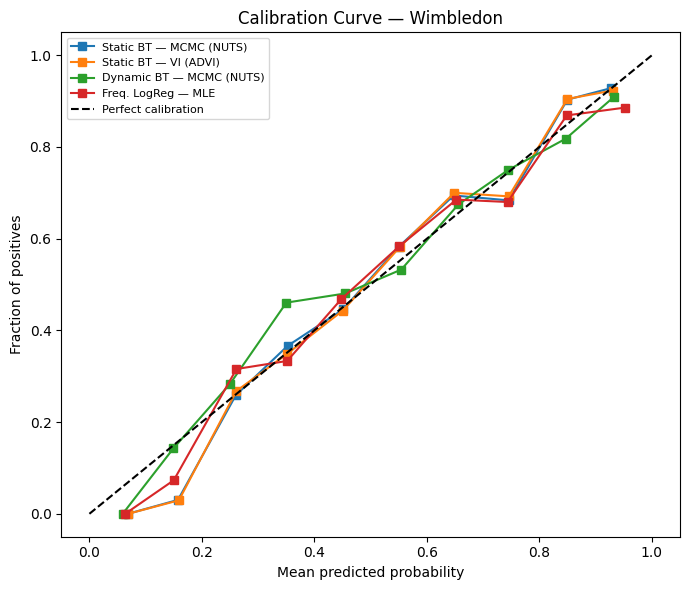


                    model  log_loss  brier_score
 Static BT — MCMC (NUTS)    0.5680       0.1938
   Static BT — VI (ADVI)    0.5683       0.1939
Dynamic BT — MCMC (NUTS)    0.5816       0.2003
      Freq. LogReg — MLE    0.6214       0.1952

Pred prob std — Static MCMC : 0.211
Pred prob std — Static VI   : 0.211
(Lower VI std may indicate overconfidence / underestimated uncertainty)


In [13]:
# =============================================================================
# SECTION 8: EVALUATION — LOG LOSS, BRIER SCORE, CALIBRATION
# Compares all four approaches on the held-out tournament.
# =============================================================================

def evaluate_predictions(y_true, y_prob, model_name="Model"):
    """Log loss, Brier score, and one calibration curve trace."""
    ll = log_loss(y_true, y_prob, labels=[0, 1])
    bs = brier_score_loss(y_true, y_prob)
    print(f"  [{model_name:28s}]  Log Loss: {ll:.4f}  |  Brier Score: {bs:.4f}")
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, "s-", label=model_name)
    return {"model": model_name, "log_loss": round(ll, 4), "brier_score": round(bs, 4)}


# ── RUN: generate all predictions ─────────────────────────────────────────────
prob_static_mcmc = predict_mcmc_static(trace_static_mcmc,  player_i_test, player_j_test)
prob_static_vi   = predict_vi_static(approx_static_vi, static_model_vi,
                                     player_i_test, player_j_test)
prob_dynamic     = predict_mcmc_dynamic(trace_dynamic_mcmc, player_i_test,
                                        player_j_test, last_period)
prob_mle         = predict_logreg(theta_mle, player_i_test, player_j_test)

# ── RUN: evaluate & calibration plot ──────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Evaluation on held-out tournament: {HELD_OUT_TOURNAMENT}")
print(f"{'='*60}")

plt.figure(figsize=(7, 6))
results = []
results.append(evaluate_predictions(y_true_test, prob_static_mcmc, "Static BT — MCMC (NUTS)"))
results.append(evaluate_predictions(y_true_test, prob_static_vi,   "Static BT — VI (ADVI)"))
results.append(evaluate_predictions(y_true_test, prob_dynamic,     "Dynamic BT — MCMC (NUTS)"))
results.append(evaluate_predictions(y_true_test, prob_mle,         "Freq. LogReg — MLE"))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title(f"Calibration Curve — {HELD_OUT_TOURNAMENT}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("calibration_all_models.png", dpi=150)
plt.show()

# Summary table
summary_df = pd.DataFrame(results)
print("\n", summary_df.to_string(index=False))

# Overconfidence check: MCMC vs VI posterior spread
print(f"\nPred prob std — Static MCMC : {prob_static_mcmc.std():.3f}")
print(f"Pred prob std — Static VI   : {prob_static_vi.std():.3f}")
print("(Lower VI std may indicate overconfidence / underestimated uncertainty)")


In [14]:
# =============================================================================
# SECTION 9: TOURNAMENT BRACKET SIMULATION
# Posterior predictive simulation over the full bracket using dynamic BT.
# =============================================================================

def simulate_full_tournament_with_rounds(draw, theta_samples, idx2player,
                                         n_simulations=5000):
    """
    Single-elimination bracket simulation.
    draw          : [[p1,p2], [p3,p4], ...]  Round-1 matchups (player indices)
    theta_samples : (S, N) posterior draws of player skill at prediction period
    Returns       : DataFrame — player x round -> reach probability
    """
    all_players = [p for pair in draw for p in pair]
    n_rounds    = int(np.log2(len(all_players)))
    round_names = [f"Round of {len(all_players) // 2**r}"
                   for r in range(n_rounds)] + ["Title"]
    reach_counts = {p: np.zeros(n_rounds + 1) for p in all_players}
    S = theta_samples.shape[0]

    for _ in range(n_simulations):
        theta           = theta_samples[np.random.randint(0, S)]
        current_bracket = [pair[:] for pair in draw]
        round_idx       = 0
        while current_bracket:
            for p in [p for pair in current_bracket for p in pair]:
                reach_counts[p][round_idx] += 1
            winners = []
            for i, j in current_bracket:
                p_i = 1 / (1 + np.exp(-(theta[i] - theta[j])))
                winners.append(i if np.random.rand() < p_i else j)
            round_idx += 1
            if len(winners) == 1:
                reach_counts[winners[0]][round_idx] += 1
                break
            current_bracket = [[winners[k], winners[k+1]]
                                for k in range(0, len(winners)-1, 2)]

    records = [
        {"player": idx2player.get(p, str(p)),
         **{rname: round(reach_counts[p][r] / n_simulations, 3)
            for r, rname in enumerate(round_names)}}
        for p in all_players
    ]
    return pd.DataFrame(records).sort_values("Title", ascending=False)


# ── RUN ───────────────────────────────────────────────────────────────────────
print("\nRunning tournament bracket simulation (dynamic BT posterior)...")

theta_all  = trace_dynamic_mcmc.posterior["theta"].values       # (C, D, N, T)
theta_flat = theta_all.reshape(-1, theta_all.shape[2], theta_all.shape[3])
theta_last = theta_flat[:, :, last_period]                       # (S, N)

wimbledon_players = test_df["winner_idx"].unique()[:8].tolist()
example_draw = [[wimbledon_players[i], wimbledon_players[i+1]]
                for i in range(0, 8, 2)]

tournament_df = simulate_full_tournament_with_rounds(
    example_draw, theta_last, idx2player, n_simulations=5000
)
print("\nTournament Probabilities:")
print(tournament_df.to_string(index=False))
tournament_df.to_csv("tournament_predictions.csv", index=False)
print("\nDone. Results saved to tournament_predictions.csv")



Running tournament bracket simulation (dynamic BT posterior)...

Tournament Probabilities:
               player  Round of 8  Round of 4  Round of 2  Title
       Novak Djokovic         1.0       0.974       0.815  0.736
Juan Martin del Potro         1.0       0.787       0.576  0.101
         Nick Kyrgios         1.0       0.578       0.115  0.084
        Kei Nishikori         1.0       0.422       0.064  0.042
         Gilles Simon         1.0       0.728       0.263  0.023
       Ernests Gulbis         1.0       0.213       0.107  0.008
          Kyle Edmund         1.0       0.026       0.006  0.003
         Benoit Paire         1.0       0.272       0.054  0.002

Done. Results saved to tournament_predictions.csv
